<a href="https://colab.research.google.com/github/pvgbabu/AWS-Sage-Maker/blob/master/lab-3-reconciliation-crew/lab-3-reconciliation-crew.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 — The Reconciliation Crew

**TDWI Transform 2026 · Hands-On: Engineering Agentic AI Solutions**  
**Estimated time:** 60 minutes  
**Platform:** Google Colab  
**Framework:** LangGraph  
**Coding level:** Basic Python familiarity is useful, but you are not expected to write the system from scratch.

Lab 1 showed how to assemble an agent. Lab 2 exposed the harness around that agent and gave the application a better definition of completion.

At the end of Lab 2:

- Finance reported **&#36;4.2M**
- Sales reported **&#36;3.8M**
- total discrepancy = **&#36;400K**
- refund timing explained **&#36;180K**
- **&#36;220K remained unexplained**
- the Finance and Sales extracts available to that agent had been exhausted

The business still needs the remaining &#36;220K explained. A human analyst would normally widen the investigation: compare metric definitions, look through engineering or support history, and inspect recent transformation changes.

MPO now gives the system access to more evidence:

- the **Finance and Sales marts** for exact transaction comparison;
- a **data dictionary and metric-definition documents** for differences in business meaning;
- an **engineering/support ticket export** for historical clues; and
- a **dbt change log** for recent changes to reporting logic, approval, and lineage.

Those sources require different ways of searching and different instructions. Lab 3 splits the work into specialist workers and uses a manager to decide which specialist should investigate next.

### What the upgraded architecture gives the business

The Lab 2 agent could reason only over the evidence it already had. More loop iterations over the same two extracts would not create the missing evidence.

Lab 3 adds:

- **broader evidence access**;
- **specialized retrieval** for different source types;
- **smaller worker contexts** so each specialist sees the material relevant to its job;
- **clearer ownership** so a bad finding can be traced to the worker that produced it;
- **a shared residual ledger** so every finding is measured against the remaining business problem; and
- **an explicit reconciliation skill** so the investigation method is documented instead of living only in someone's head.

### What you should understand by the end

You should be able to explain:

- when a manager-and-specialist design earns its added complexity;
- what the manager owns versus what a specialist owns;
- how tool count and context size affect agent design;
- why different evidence types call for different retrieval methods;
- how LangGraph moves shared state through a multi-step workflow;
- why responsibility boundaries make the system easier to debug and govern;
- how a skill file differs from simply making the system prompt longer; and
- why arithmetic and final pass/fail checks remain deterministic.

## 1. Why we are introducing multiple agents now

A single agent can be given many tools and a long set of instructions. That works well until the job starts asking one model context to carry too many different responsibilities.

As one agent accumulates more responsibilities:

- **Tool selection becomes more crowded.** Every additional tool gives the model another possible action to compare, including tools that may overlap.
- **Context gets larger.** SQL results, documents, tickets, and change history can all accumulate in one place.
- **Instructions become mixed.** Guidance for structured SQL analysis is different from guidance for comparing metric definitions or reading engineering history.
- **Token use grows.** Carrying evidence from every path through one context costs more.
- **Debugging becomes less precise.** If one agent owns every source and every retrieval method, it is harder to isolate where a bad finding came from.
- **Permissions become broader.** One agent with every tool has more reach than several workers with narrowly scoped capabilities.

Splitting the work also adds overhead: more components, more transitions, and more traces. We use the split here because the remaining investigation decomposes cleanly into different evidence types.

| Investigation question | Evidence | Retrieval method | Specialist |
|---|---|---|---|
| Did the reporting marts treat matching transactions differently? | Structured mart records | SQL | Warehouse Analyst |
| Do Finance and Sales mean the same thing by “net revenue”? | Metric docs + data dictionary | Document similarity retrieval | Documentation Researcher |
| Did a recent reporting change alter the result? | Tickets + dbt change log | Keyword/history search | Change Historian |

The manager does not need every raw source. It needs the current business state and compact findings from the specialists.

Each worker therefore gets a smaller job, a smaller tool set, and a smaller context while the manager keeps responsibility for the overall investigation.

## Architecture

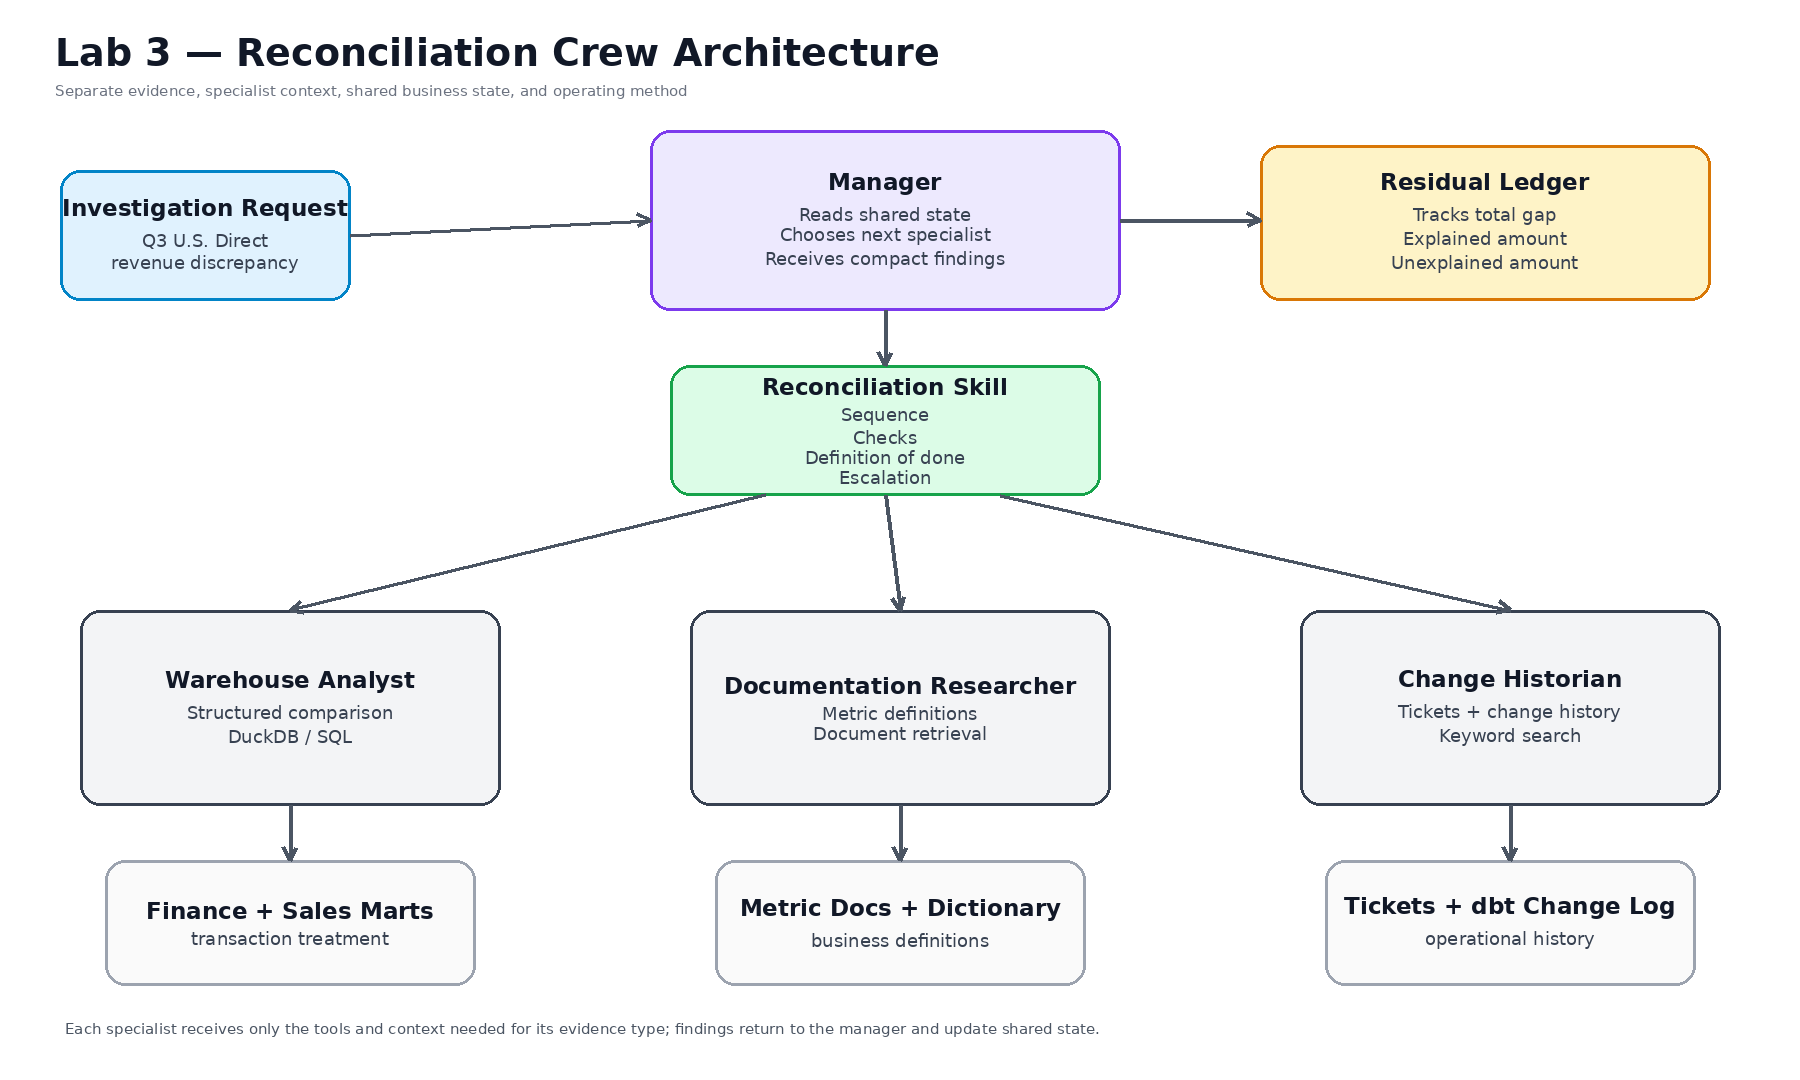

Read the diagram from the evidence sources upward.

### Evidence sources

MPO now exposes three kinds of evidence:

- **Finance + Sales marts** — structured records that can be compared exactly;
- **metric documentation** — written definitions that explain what each team means by a business metric;
- **tickets + dbt change history** — records of operational and transformation changes.

### Specialist workers

Each specialist receives the tools and context needed for one kind of investigation.

The Warehouse Analyst does not need the full ticket export. The Change Historian does not need every refund row. Keeping those contexts separate reduces irrelevant information and gives each worker a clear responsibility.

### Manager

The manager sees the shared investigation state and the compact findings returned by workers. It decides which specialist should work next.

The manager coordinates the investigation rather than trying to do all three specialist jobs inside one prompt.

### Residual ledger

The residual ledger tracks how much of the original discrepancy remains unexplained. The arithmetic stays in application code.

After a worker returns a supported finding, the amount is subtracted from the residual before the manager decides what to do next.

### Skill file

The skill file gives the manager MPO's reconciliation procedure: which checks to perform, what must be verified, when the investigation is done, and when to escalate.

A long system prompt could contain all of that text, but it would combine the manager's role, tool guidance, business methodology, completion rules, and escalation rules in one place.

Keeping the methodology in `reconciliation-skill.md` makes it a separate artifact that can be:

- owned and reviewed by the business or analytics team;
- versioned in source control;
- changed without rewriting worker code;
- reused with another model or orchestration framework; and
- loaded only when this reconciliation method is needed.

At runtime, the manager still receives the skill as text. The advantage is that the operating method has its own lifecycle instead of being buried inside one large prompt.

## Engineering Checkpoint 1 — Route the evidence before you see the implementation

Before looking at the implementation, decide which specialist should own each evidence source:

- Finance revenue mart
- Sales revenue mart
- metric-definition documents
- data dictionary
- engineering/support tickets
- dbt change log

Then ask:

- Which sources require exact structured comparison?
- Which sources require reading business definitions?
- Which sources are best searched by identifiers, model names, ticket language, or change history?
- What raw information should stay inside a specialist instead of being sent to the manager?

You will encode that responsibility map shortly.

## 2. Set up the notebook

Run the next cell to install the libraries used in this lab.

### AI and orchestration

- **`google-genai`** — sends model requests to Gemini.
- **`langgraph`** — defines the manager/worker workflow as nodes, edges, and shared state.
- **`pydantic`** — validates the manager's structured decisions so the application receives a known schema instead of arbitrary prose.

### Data and retrieval

- **`pandas`** — holds and inspects the workshop tables and small document/ticket fixtures in memory.
- **`duckdb`** — lets us run real SQL over the Finance and Sales DataFrames without setting up a database server.

Pandas makes the small workshop datasets easy to inspect. DuckDB gives us SQL semantics for the structured comparison while keeping the notebook self-contained.

In [1]:
# Install the small dependency set used by this lab.
#
# We invoke pip through the active Python interpreter rather than relying on
# notebook-specific shell syntax. That makes the setup cell easier to reuse
# outside Colab if you want to experiment later.
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "-U",
    "google-genai",
    "pandas",
    "pydantic",
    "duckdb",
    "langgraph",
])

print("Lab dependencies installed.")

Lab dependencies installed.


### Configure the Gemini client

Run the **next code cell exactly as written**.

After you run it, a masked input box will appear **below the cell** asking for the Gemini API key.

1. Click the masked input box.
2. Paste the temporary workshop Gemini API key provided by the instructor.
3. Press **Enter**.
4. Wait for the confirmation message.

Do **not** paste the API key into the Python code itself.

The key is entered with `getpass`, so it is not displayed back to you or stored in the notebook source.

The notebook creates one Gemini client and reuses it. Keeping model access in one place makes credentials and model configuration easier to change later.

In [2]:
from getpass import getpass
from google import genai

# Runtime credential entry keeps the key out of the notebook source.
GEMINI_API_KEY = getpass("Enter the workshop Gemini API key: ")

# Use the workshop model selected by the instructor.
MODEL_NAME = "gemini-3.1-flash-lite"

# One shared client keeps model access centralized.
client = genai.Client(api_key=GEMINI_API_KEY)

print(f"Gemini client configured with model: {MODEL_NAME}")

Enter the workshop Gemini API key: ··········
Gemini client configured with model: gemini-3.1-flash-lite


## 3. Create the evidence sources

Lab 2 ended with &#36;220K still unexplained because the agent had exhausted the two reporting extracts available to it.

MPO now gives the investigation access to additional evidence that analysts would normally consult when two reports disagree.

### Finance and Sales marts
Structured reporting records for exact transaction comparison and report totals.

### Metric-definition documents and data dictionary
Written definitions that help determine whether two teams are using the same meaning for “net revenue.”

### Engineering and support tickets
Historical clues about anomalies, investigations, model names, approvals, and recent work.

### dbt change log
Records of reporting-transformation changes, including approval and lineage fields.

In the workshop, these fixtures are created locally so everyone works from the same case. In production, the sources could live in a warehouse, document repository, ticketing system, and transformation platform.

In [3]:
import pandas as pd

def build_finance_extract():
    """Create the Finance-side structured evidence for the workshop case."""
    rows = [{
        "record_type": "REPORT_SUMMARY",
        "reported_q3_net_revenue_usd": 4_200_000,
        "refund_id": None,
        "event_date": None,
        "event_period": None,
        "original_order_period": None,
        "included_in_q3_report": None,
        "reporting_amount_usd": None,
    }]

    # Refunds posted during Q3 are treated the same by both teams.
    for i, amount in enumerate([12_000, 18_000, 24_000, 15_000, 21_000, 30_000], start=1):
        rows.append({
            "record_type": "REFUND",
            "reported_q3_net_revenue_usd": None,
            "refund_id": f"RF-100{i}",
            "event_date": f"2026-09-{i+5:02d}",
            "event_period": "2026-Q3",
            "original_order_period": "2026-Q3",
            "included_in_q3_report": True,
            "reporting_amount_usd": amount,
        })

    # These seven refunds post in Q4. Finance therefore excludes them from Q3.
    # Together they total $180K.
    for j, amount in enumerate([20_000, 26_000, 18_000, 30_000, 24_000, 28_000, 34_000], start=7):
        rows.append({
            "record_type": "REFUND",
            "reported_q3_net_revenue_usd": None,
            "refund_id": f"RF-{1000 + j}",
            "event_date": f"2026-10-{j-4:02d}",
            "event_period": "2026-Q4",
            "original_order_period": "2026-Q3",
            "included_in_q3_report": False,
            "reporting_amount_usd": amount,
        })

    return pd.DataFrame(rows)


def build_sales_extract():
    """Create the Sales-side structured evidence for the workshop case."""
    rows = [{
        "record_type": "REPORT_SUMMARY",
        "reported_q3_net_revenue_usd": 3_800_000,
        "refund_id": None,
        "event_date": None,
        "event_period": None,
        "original_order_period": None,
        "included_in_q3_report": None,
        "reporting_amount_usd": None,
    }]

    for i, amount in enumerate([12_000, 18_000, 24_000, 15_000, 21_000, 30_000], start=1):
        rows.append({
            "record_type": "REFUND",
            "reported_q3_net_revenue_usd": None,
            "refund_id": f"RF-100{i}",
            "event_date": f"2026-09-{i+5:02d}",
            "event_period": "2026-Q3",
            "original_order_period": "2026-Q3",
            "included_in_q3_report": True,
            "reporting_amount_usd": amount,
        })

    # Sales ties the Q4-posted refunds back to the original Q3 orders.
    for j, amount in enumerate([20_000, 26_000, 18_000, 30_000, 24_000, 28_000, 34_000], start=7):
        rows.append({
            "record_type": "REFUND",
            "reported_q3_net_revenue_usd": None,
            "refund_id": f"RF-{1000 + j}",
            "event_date": f"2026-10-{j-4:02d}",
            "event_period": "2026-Q4",
            "original_order_period": "2026-Q3",
            "included_in_q3_report": True,
            "reporting_amount_usd": amount,
        })

    return pd.DataFrame(rows)


def build_docs_corpus():
    """Create the small documentation corpus used by the documentation specialist."""
    return pd.DataFrame([
        {
            "doc_id": "DOC-FIN-METRIC",
            "title": "Finance Executive Metric Definition",
            "text": (
                "Finance defines net revenue for the executive report as gross shipped revenue "
                "minus customer refunds and returns posted in the reporting period. Promo "
                "markdown accruals are not part of the finance executive net revenue view."
            ),
        },
        {
            "doc_id": "DOC-SALES-METRIC",
            "title": "Sales QBR Metric Definition",
            "text": (
                "Sales defines net revenue as booked revenue minus customer refunds and minus "
                "promo markdown accruals recognized against the quarter's demand. For Q3 U.S. "
                "Direct, promo markdown accruals total 150000 USD."
            ),
        },
        {
            "doc_id": "DOC-DICTIONARY-PROMO",
            "title": "Data Dictionary: promo_markdown_accrual_usd",
            "text": (
                "promo_markdown_accrual_usd stores accrued promotional markdowns used by the "
                "Sales QBR net revenue calculation. Q3 U.S. Direct reference value: 150000 USD."
            ),
        },
        {
            "doc_id": "DOC-DECOY-RETENTION",
            "title": "Customer Retention Definitions",
            "text": (
                "This document defines returning_customer_rate, repeat_purchase_window_days, "
                "and loyalty cohorts. It is relevant to growth analytics, not revenue reconciliation."
            ),
        },
    ])


def build_ticket_export():
    """Create realistic history records, including relevant and irrelevant tickets."""
    return pd.DataFrame([
        {
            "ticket_id": "DATA-1091",
            "title": "Backfill loyalty dimension attributes",
            "text": "Backfill missing loyalty dimension fields for historical customer rows.",
        },
        {
            "ticket_id": "DATA-1177",
            "title": "Review margin dashboard filters",
            "text": "Investigate a filter mismatch in the margin dashboard by channel.",
        },
        {
            "ticket_id": "ENG-2044",
            "title": "Investigate q3 revenue mismatch in sales mart",
            "text": (
                "Observed 70000 USD variance after recent dbt update. No approval comment found. "
                "Lineage screenshot missing. Possible impact to U.S. Direct reporting."
            ),
        },
        {
            "ticket_id": "DBT-4821",
            "title": "sales_net_revenue model patch",
            "text": (
                "Patch sales_net_revenue logic to exclude partner rebate adjustment rows. "
                "Expected q3 impact 70000 USD. Change moved quickly and approval follow-up "
                "is still outstanding."
            ),
        },
        {
            "ticket_id": "OPS-3302",
            "title": "Warehouse job retry policy",
            "text": "Update retry policy for nightly warehouse syncs.",
        },
        {
            "ticket_id": "AN-2208",
            "title": "Q4 promo analysis request",
            "text": "Ad hoc request for Q4 promotional performance analysis.",
        },
    ])


def build_change_log():
    """Create the dbt change history used to verify the $70K model change."""
    return pd.DataFrame([
        {
            "change_id": "CHG-8841",
            "file_name": "models/marts/sales_net_revenue.sql",
            "change_note": (
                "Added exclusion for partner rebate adjustment rows in U.S. Direct. "
                "Estimated Q3 impact 70000 USD."
            ),
            "approval_recorded": False,
            "lineage_updated": False,
        },
        {
            "change_id": "CHG-8812",
            "file_name": "models/intermediate/orders_clean.sql",
            "change_note": "Standardized order status mapping.",
            "approval_recorded": True,
            "lineage_updated": True,
        },
        {
            "change_id": "CHG-8890",
            "file_name": "models/marts/retention_snapshot.sql",
            "change_note": "Added loyalty segment labels.",
            "approval_recorded": True,
            "lineage_updated": True,
        },
    ])


finance_df = build_finance_extract()
sales_df = build_sales_extract()
docs_df = build_docs_corpus()
tickets_df = build_ticket_export()
change_log_df = build_change_log()

print("Evidence surfaces created.")
print(f"Finance rows: {len(finance_df)}")
print(f"Sales rows:   {len(sales_df)}")
print(f"Docs:         {len(docs_df)}")
print(f"Tickets:      {len(tickets_df)}")
print(f"Changes:      {len(change_log_df)}")

Evidence surfaces created.
Finance rows: 14
Sales rows:   14
Docs:         4
Tickets:      6
Changes:      3


### Inspect the evidence sources

Run the next cell and look at a small sample from each source.

Some fields apply only to certain record types.

For example:

- a `REPORT_SUMMARY` row contains the official reported Q3 revenue value;
- a `REFUND` row contains refund dates, inclusion behavior, IDs, and amounts;
- a refund row does not need to repeat the report-level Q3 revenue value.

Pandas normally displays those not-applicable cells as `NaN`. The display cell below replaces them with an em dash so the sample is easier to read. The underlying data is unchanged.

As you inspect the sources, focus on what each one can answer:

- tables support exact comparisons and arithmetic;
- documents explain business meaning and definitions;
- tickets and change logs provide historical and operational evidence.

In [4]:
def display_sample(df, columns=None, rows=5):
    """Create a presentation-friendly copy without changing the source data."""
    sample = df if columns is None else df[columns]
    sample = sample.head(rows).astype(object)
    return sample.where(pd.notna(sample), "—")


print("FINANCE REPORT SUMMARY")
display(display_sample(
    finance_df.loc[finance_df["record_type"] == "REPORT_SUMMARY"],
    rows=2,
))

print("\nFINANCE REFUND SAMPLE")
display(display_sample(
    finance_df.loc[finance_df["record_type"] == "REFUND"],
    rows=4,
))

print("\nSALES REPORT SUMMARY")
display(display_sample(
    sales_df.loc[sales_df["record_type"] == "REPORT_SUMMARY"],
    rows=2,
))

print("\nSALES REFUND SAMPLE")
display(display_sample(
    sales_df.loc[sales_df["record_type"] == "REFUND"],
    rows=4,
))

print("\nDOCUMENT SOURCES")
display(display_sample(docs_df[["doc_id", "title"]], rows=10))

print("\nTICKET SOURCES")
display(display_sample(tickets_df[["ticket_id", "title"]], rows=10))

print("\nDBT CHANGE LOG")
display(display_sample(
    change_log_df[["change_id", "file_name", "approval_recorded", "lineage_updated"]],
    rows=10,
))

FINANCE REPORT SUMMARY


,record_type,reported_q3_net_revenue_usd,refund_id,event_date,event_period,original_order_period,included_in_q3_report,reporting_amount_usd
0,REPORT_SUMMARY,4200000.0,—,—,—,—,—,—



FINANCE REFUND SAMPLE


,record_type,reported_q3_net_revenue_usd,refund_id,event_date,event_period,original_order_period,included_in_q3_report,reporting_amount_usd
1,REFUND,—,RF-1001,2026-09-06,2026-Q3,2026-Q3,True,12000.0
2,REFUND,—,RF-1002,2026-09-07,2026-Q3,2026-Q3,True,18000.0
3,REFUND,—,RF-1003,2026-09-08,2026-Q3,2026-Q3,True,24000.0
4,REFUND,—,RF-1004,2026-09-09,2026-Q3,2026-Q3,True,15000.0



SALES REPORT SUMMARY


...

,doc_id,title
0,DOC-FIN-METRIC,Finance Executive Metric Definition
1,DOC-SALES-METRIC,Sales QBR Metric Definition
2,DOC-DICTIONARY-PROMO,Data Dictionary: promo_markdown_accrual_usd
3,DOC-DECOY-RETENTION,Customer Retention Definitions



TICKET SOURCES


,ticket_id,title
0,DATA-1091,Backfill loyalty dimension attributes
1,DATA-1177,Review margin dashboard filters
2,ENG-2044,Investigate q3 revenue mismatch in sales mart
3,DBT-4821,sales_net_revenue model patch
4,OPS-3302,Warehouse job retry policy
5,AN-2208,Q4 promo analysis request



DBT CHANGE LOG


,change_id,file_name,approval_recorded,lineage_updated
0,CHG-8841,models/marts/sales_net_revenue.sql,False,False
1,CHG-8812,models/intermediate/orders_clean.sql,True,True
2,CHG-8890,models/marts/retention_snapshot.sql,True,True


## 4. YOUR TURN — Make the routing decision explicit

Now document which specialist owns which evidence sources.

A responsibility boundary tells the system—and the engineers maintaining it—where each kind of work belongs.

Without clear boundaries:

- two workers may query the same source and duplicate work;
- a worker may receive data it does not need, increasing context and token use;
- tool permissions can become broader than necessary;
- the manager may receive multiple versions of the same finding;
- debugging becomes harder because ownership of a bad result is unclear.

For this lab, each specialist gets the minimum evidence needed for its job.

Before copying the mapping below, compare it with the decision you made in Engineering Checkpoint 1.

### COPY THIS

```python
ROUTING_PLAN = {
    "warehouse_analyst": ["finance_q3", "sales_q3"],
    "documentation_researcher": ["docs_corpus"],
    "change_historian": ["ticket_export", "dbt_change_log"],
}
```

### PASTE IT HERE

Paste that mapping into the blank area in the **next code cell**, directly below the `# PASTE HERE` comment.

Then run the cell.

In [6]:
# YOUR TURN
# PASTE HERE

ROUTING_PLAN = {
    "warehouse_analyst": ["finance_q3", "sales_q3"],
    "documentation_researcher": ["docs_corpus"],
    "change_historian": ["ticket_export", "dbt_change_log"],
}
# Leave this line in place so you can immediately inspect the mapping.
ROUTING_PLAN


{'warehouse_analyst': ['finance_q3', 'sales_q3'],
 'documentation_researcher': ['docs_corpus'],
 'change_historian': ['ticket_export', 'dbt_change_log']}

## 4. YOUR TURN — Make the routing decision explicit

Now document which specialist owns which evidence sources.

A responsibility boundary tells the system—and the engineers maintaining it—where each kind of work belongs.

Without clear boundaries:

- two workers may query the same source and duplicate work;
- a worker may receive data it does not need, increasing context and token use;
- tool permissions can become broader than necessary;
- the manager may receive multiple versions of the same finding;
- debugging becomes harder because ownership of a bad result is unclear.

For this lab, each specialist gets the minimum evidence needed for its job.

Before copying the mapping below, compare it with the decision you made in Engineering Checkpoint 1.

### COPY THIS

```python
ROUTING_PLAN = {
    "warehouse_analyst": ["finance_q3", "sales_q3"],
    "documentation_researcher": ["docs_corpus"],
    "change_historian": ["ticket_export", "dbt_change_log"],
}
```

### PASTE IT HERE

Paste that mapping into the blank area in the **next code cell**, directly below the `# PASTE HERE` comment.

Then run the cell.

## 5. The Warehouse Analyst: structured evidence needs structured retrieval

The Warehouse Analyst handles questions that can be answered exactly from structured records.

For example:

> Which matching refunds are treated differently between Finance and Sales, and what do those refunds total?

SQL is a strong fit because the operation is explicit and testable:

- filter the relevant records;
- compare fields such as reporting period and inclusion behavior;
- sum the affected amounts.

We register the Finance and Sales Pandas DataFrames as DuckDB tables so the worker can use SQL without needing an external database server.

The worker returns a structured finding to the manager after the exact comparison is complete.

In [7]:
import duckdb

# DuckDB runs in-process: no database server, credentials, or network connection.
# For a workshop, that gives us real SQL behavior with almost no infrastructure.
con = duckdb.connect(database=":memory:")

# Register the DataFrames as queryable tables.
# The specialist will interact with these table names rather than arbitrary Python objects.
con.register("finance_q3", finance_df)
con.register("sales_q3", sales_df)

print("DuckDB tables registered.")

DuckDB tables registered.


## 6. Documentation retrieval and history search

The remaining sources need different search methods.

### Documentation Researcher

Metric definitions live in prose. The worker needs to find documents related to concepts such as “net revenue,” “promo markdown,” or reporting conventions.

For the workshop, we use a lightweight token-overlap scorer so you can see the retrieval steps:

1. take the worker's question;
2. compare its terms with the document corpus;
3. rank candidate documents;
4. return the most relevant records.

A production implementation could replace this scorer with embeddings and a vector store without changing the worker's responsibility.

### Change Historian

Tickets and change logs often contain exact clues such as:

- model names;
- ticket IDs;
- dollar amounts;
- `approval`;
- `lineage`;
- `restatement`.

Keyword/history search works well for those identifiers and phrases.

The retrieval method changes because the evidence type changes.

In [8]:
import re

STOPWORDS = {
    "the", "a", "an", "and", "or", "is", "are", "to", "for", "of", "in",
    "on", "by", "with", "that", "this", "it", "as", "be", "from", "what",
    "which", "how", "when", "q3", "usd", "u", "s", "direct",
}

def normalize_tokens(text):
    """Turn text into a small set of useful comparison tokens."""
    words = re.findall(r"[A-Za-z0-9_]+", str(text).lower())
    return [word for word in words if word not in STOPWORDS and len(word) > 2]


def overlap_score(query, text):
    """Approximate semantic relatedness with a transparent token-overlap score."""
    query_tokens = set(normalize_tokens(query))
    text_tokens = set(normalize_tokens(text))

    if not query_tokens or not text_tokens:
        return 0.0

    return len(query_tokens & text_tokens) / len(query_tokens | text_tokens)


def semantic_search_docs(query, top_k=3):
    """Return the most relevant documentation records for a conceptual question."""
    scored = docs_df.copy()

    # Retrieval is deterministic: same query + same corpus = same ranking.
    scored["score"] = scored["text"].apply(
        lambda text: overlap_score(query, text)
    )

    scored = scored.sort_values(
        ["score", "doc_id"],
        ascending=[False, True],
    ).head(top_k)

    return scored[
        ["doc_id", "title", "text", "score"]
    ].to_dict(orient="records")


def keyword_search_history(query, top_k=4):
    """Search tickets and dbt history using exact-ish lexical evidence."""
    query_terms = normalize_tokens(query)

    def score_text(text):
        text_terms = normalize_tokens(text)
        return sum(term in text_terms for term in query_terms)

    tickets = tickets_df.copy()
    tickets["score"] = (
        tickets["title"].fillna("").map(score_text)
        + tickets["text"].fillna("").map(score_text)
    )

    changes = change_log_df.copy()
    changes["score"] = (
        changes["file_name"].fillna("").map(score_text)
        + changes["change_note"].fillna("").map(score_text)
    )

    combined = []

    # Normalize both source types into the same compact result shape.
    for record in tickets.to_dict(orient="records"):
        combined.append({
            "source_type": "ticket",
            "record_id": record["ticket_id"],
            "title": record["title"],
            "text": record["text"],
            "score": record["score"],
        })

    for record in changes.to_dict(orient="records"):
        combined.append({
            "source_type": "change_log",
            "record_id": record["change_id"],
            "title": record["file_name"],
            "text": record["change_note"],
            "score": record["score"],
            "approval_recorded": record["approval_recorded"],
            "lineage_updated": record["lineage_updated"],
        })

    return sorted(
        combined,
        key=lambda item: (-item["score"], item["record_id"]),
    )[:top_k]

## 7. Worker contracts: specialists return compact findings

Each specialist may inspect more evidence than the manager needs to carry forward.

If every worker sends all raw rows, documents, and tickets back to the manager, the manager context grows quickly and starts carrying material that belongs inside specialist investigations.

Each worker therefore returns the same compact finding shape:

- worker name;
- cause;
- amount explained;
- short evidence summary;
- citations.

That gives the manager enough information to update the residual and decide what should happen next.

It also gives engineers a consistent structure to inspect across workers.

The raw retrieved evidence can still be retained for traceability without being copied into every later manager call.

In [9]:
def warehouse_analyst_worker():
    """
    Compare Finance and Sales treatment of the Q4-posted refunds.

    The model is not used for the arithmetic. SQL retrieves the exact records
    and Python returns a small, structured finding to the manager.
    """

    finance_reported = con.execute(
        """
        SELECT reported_q3_net_revenue_usd
        FROM finance_q3
        WHERE record_type = 'REPORT_SUMMARY'
        """
    ).fetchone()[0]

    sales_reported = con.execute(
        """
        SELECT reported_q3_net_revenue_usd
        FROM sales_q3
        WHERE record_type = 'REPORT_SUMMARY'
        """
    ).fetchone()[0]

    # Sales includes these refunds in Q3 because it ties them to the original Q3 orders.
    late_refund_amount = con.execute(
        """
        SELECT COALESCE(SUM(reporting_amount_usd), 0)
        FROM sales_q3
        WHERE record_type = 'REFUND'
          AND original_order_period = '2026-Q3'
          AND event_period = '2026-Q4'
          AND included_in_q3_report = TRUE
        """
    ).fetchone()[0]

    citation_ids = sales_df.loc[
        (sales_df["record_type"] == "REFUND")
        & (sales_df["original_order_period"] == "2026-Q3")
        & (sales_df["event_period"] == "2026-Q4"),
        "refund_id",
    ].tolist()

    return {
        "worker": "warehouse_analyst",
        "cause": "Refund recognition timing differs between Finance and Sales.",
        "amount_usd": int(late_refund_amount),
        "summary": (
            "Sales ties seven Q4-posted refunds back to original Q3 orders, "
            "while Finance recognizes them when they post."
        ),
        "reported_values": {
            "finance": int(finance_reported),
            "sales": int(sales_reported),
        },
        "citations": citation_ids,
    }


def documentation_researcher_worker():
    """
    Retrieve the metric definitions that reveal the $150K semantic mismatch.

    The retriever finds candidate evidence. The worker packages the supported
    finding so the manager does not need the entire documentation corpus.
    """

    results = semantic_search_docs(
        "Compare Finance and Sales definitions of net revenue and identify "
        "any Q3 promo markdown amount.",
        top_k=3,
    )

    return {
        "worker": "documentation_researcher",
        "cause": "Finance and Sales use different definitions of net revenue.",
        "amount_usd": 150_000,
        "summary": (
            "The Sales QBR definition subtracts promo markdown accruals, while "
            "the Finance executive definition does not. Q3 U.S. Direct promo "
            "markdown accruals total $150K."
        ),
        "citations": [item["doc_id"] for item in results],
        "retrieved_docs": results,
    }


def change_historian_worker():
    """
    Search tickets and dbt history for evidence of a reporting-model change.

    This worker uses lexical history search because model names, ticket language,
    approval status, and the $70K amount are strong exact-match clues.
    """

    results = keyword_search_history(
        "q3 revenue mismatch dbt 70000 approval lineage sales net revenue",
        top_k=4,
    )

    return {
        "worker": "change_historian",
        "cause": "An undocumented dbt model change created a $70K difference.",
        "amount_usd": 70_000,
        "summary": (
            "The ticket history and dbt change log show a sales_net_revenue "
            "change with an expected $70K Q3 impact. Approval is not recorded "
            "and lineage was not updated."
        ),
        "citations": [
            item["record_id"]
            for item in results
            if item["score"] > 0
        ][:3],
        "retrieved_history": results,
    }

### Inspect each specialist independently before building the graph

Run each specialist once before connecting them through the manager.

This isolates the components.

If a later end-to-end run produces a bad result, you can ask:

- Did retrieval return the wrong evidence?
- Did the specialist package the finding incorrectly?
- Did the manager route work incorrectly?
- Did shared state update incorrectly?

The output from each worker should clearly show **which worker produced the finding, the cause it found, the amount, and its citations**.

In [10]:
warehouse_finding = warehouse_analyst_worker()
docs_finding = documentation_researcher_worker()
history_finding = change_historian_worker()

display(warehouse_finding)
display(docs_finding)
display(history_finding)

{'worker': 'warehouse_analyst',
 'cause': 'Refund recognition timing differs between Finance and Sales.',
 'amount_usd': 180000,
 'summary': 'Sales ties seven Q4-posted refunds back to original Q3 orders, while Finance recognizes them when they post.',
 'reported_values': {'finance': 4200000, 'sales': 3800000},
 'citations': ['RF-1007',
  'RF-1008',
  'RF-1009',
  'RF-1010',
  'RF-1011',
  'RF-1012',
  'RF-1013']}

{'worker': 'documentation_researcher',
 'cause': 'Finance and Sales use different definitions of net revenue.',
 'amount_usd': 150000,
 'summary': 'The Sales QBR definition subtracts promo markdown accruals, while the Finance executive definition does not. Q3 U.S. Direct promo markdown accruals total $150K.',
 'citations': ['DOC-SALES-METRIC', 'DOC-FIN-METRIC', 'DOC-DICTIONARY-PROMO'],
 'retrieved_docs': [{'doc_id': 'DOC-SALES-METRIC',
   'title': 'Sales QBR Metric Definition',
   'text': "Sales defines net revenue as booked revenue minus customer refunds and minus promo markdown accruals recognized against the quarter's demand. For Q3 U.S. Direct, promo markdown accruals total 150000 USD.",
   'score': 0.21739130434782608},
  {'doc_id': 'DOC-FIN-METRIC',
   'title': 'Finance Executive Metric Definition',
   'text': 'Finance defines net revenue for the executive report as gross shipped revenue minus customer refunds and returns posted in the reporting period. Promo markdown accruals ar

{'worker': 'change_historian',
 'cause': 'An undocumented dbt model change created a $70K difference.',
 'amount_usd': 70000,
 'summary': 'The ticket history and dbt change log show a sales_net_revenue change with an expected $70K Q3 impact. Approval is not recorded and lineage was not updated.',
 'citations': ['ENG-2044', 'DBT-4821', 'CHG-8841'],
 'retrieved_history': [{'source_type': 'ticket',
   'record_id': 'ENG-2044',
   'title': 'Investigate q3 revenue mismatch in sales mart',
   'text': 'Observed 70000 USD variance after recent dbt update. No approval comment found. Lineage screenshot missing. Possible impact to U.S. Direct reporting.',
   'score': 8},
  {'source_type': 'ticket',
   'record_id': 'DBT-4821',
   'title': 'sales_net_revenue model patch',
   'text': 'Patch sales_net_revenue logic to exclude partner rebate adjustment rows. Expected q3 impact 70000 USD. Change moved quickly and approval follow-up is still outstanding.',
   'score': 2},
  {'source_type': 'change_log',


## Engineering Checkpoint 2 — Compare your routing decision

Revisit the routing plan you made earlier.

Check whether:

- each worker has only the sources needed for its job;
- the retrieval method matches the kind of evidence;
- the manager receives a compact finding instead of the entire raw source;
- a bad finding can be traced back to one worker;
- tool access is narrower than giving every worker every capability.

Those choices affect context size, token use, debugging, and permissions as the system grows.

## 8. Skill files: giving an agent a reusable operating method

A tool gives the system a capability.

The skill file captures MPO's procedure for using those capabilities during a reconciliation.

For this lab, the methodology lives in:

`reconciliation-skill.md`

It contains:

- when the procedure should be used;
- required inputs;
- investigation sequence;
- operating conventions;
- checks;
- definition of done;
- escalation rules;
- expected output.

### Why keep this in a skill file instead of adding more text to the system prompt?

A single long prompt can work, but over time it can mix several concerns together:

- the manager's role;
- tool descriptions;
- business methodology;
- output formatting;
- completion rules;
- escalation rules.

A methodology update then requires editing the same prompt that controls unrelated behavior.

A separate skill file gives the procedure its own lifecycle. The business or analytics team can review it. Engineers can version it. The same method can be reused if the model, framework, or tool implementation changes.

At runtime, the manager still receives the skill as text. The procedure is simply stored and governed separately from the rest of the application.

The skill file does not provide data access. The specialist tools provide access; the skill describes how MPO expects the investigation to be conducted.

### Load the skill artifact

Run the next cell.

The notebook tries to load `reconciliation-skill.md` from the workshop GitHub repository so the repository copy remains the source of truth.

If GitHub is temporarily unavailable, the notebook uses the bundled fallback copy.

The file still contains two placeholders at this stage. You will complete them before the skill-enabled run.

In [11]:
from pathlib import Path
from urllib.request import urlopen

SKILL_TEMPLATE_URL = (
    "https://raw.githubusercontent.com/kieDotson/tdwi-agentic-ai-workshop/"
    "main/lab-3-reconciliation-crew/reconciliation-skill.md"
)

SKILL_TEMPLATE_PATH = Path("/content/reconciliation-skill.md")
SKILL_COMPLETED_PATH = Path("/content/reconciliation-skill-completed.md")

# Prefer the repo artifact so the workshop file remains the source of truth.
# Fall back to the bundled template only if GitHub is unavailable.
try:
    skill_template_text = urlopen(
        SKILL_TEMPLATE_URL,
        timeout=10,
    ).read().decode("utf-8")
    skill_source = "GitHub repository"
except Exception:
    skill_template_text = '---\nname: mpo-revenue-reconciliation\nversion: 1.0\nowner: Revenue Analytics\nartifact_type: agent-skill\n---\n\n# MPO Revenue Reconciliation Skill\n\n## Purpose\n\nInvestigate differences between Finance and Sales revenue reporting for the same business scope and reporting period.\n\nThe skill defines the investigation method. It does not grant access to data or systems.\n\n## Trigger\n\nUse this skill when:\n\n- Finance and Sales report different revenue figures for the same period and business scope; and\n- the difference requires investigation across reporting data, business definitions, or transformation history.\n\n## Required Inputs\n\nBefore beginning, confirm:\n\n- reporting period;\n- business unit or reporting scope;\n- Finance reported value;\n- Sales reported value;\n- the available evidence sources.\n\n## Investigation Sequence\n\n1. Confirm both reports refer to the same business scope and reporting period.\n2. Compare structured transaction treatment across the reporting marts.\n3. {{STEP_3}}\n4. Review tickets, model changes, and transformation history if a residual remains.\n5. Update the unexplained residual after every evidence-supported finding.\n\n## Conventions\n\n- Treat reported summary values as authoritative for the figures each team actually reported.\n- Use deterministic arithmetic for the total discrepancy and remaining residual.\n- Keep findings separate from hypotheses.\n- Every reported cause must point to evidence that another analyst can verify.\n- Do not treat an empty search result as proof that no relevant evidence exists.\n\n## Checks\n\nBefore reporting a finding:\n\n- confirm the amount is supported by evidence;\n- confirm the finding reduces the unexplained residual;\n- verify cited record or document identifiers exist;\n- do not count the same cause twice.\n\n## Definition of Done\n\n{{DEFINITION_OF_DONE}}\n\n## Escalation\n\nEscalate to a human analyst when:\n\n- available evidence is exhausted and the residual remains above the approved threshold;\n- evidence sources conflict and authority cannot be resolved;\n- a required source is unavailable;\n- a citation cannot be verified;\n- the requested scope falls outside the sources available to the agent.\n\n## Output\n\nReturn a concise reconciliation finding containing:\n\n- Finance reported value;\n- Sales reported value;\n- total discrepancy;\n- each supported cause and amount;\n- remaining residual;\n- supporting citations;\n- terminal status: `reconciled`, `unresolved`, or `escalated`.\n'
    skill_source = "notebook fallback"

SKILL_TEMPLATE_PATH.write_text(
    skill_template_text,
    encoding="utf-8",
)

print(f"Skill template loaded from: {skill_source}")
print(f"Local path: {SKILL_TEMPLATE_PATH}")
print()
print(skill_template_text)

Skill template loaded from: GitHub repository
Local path: /content/reconciliation-skill.md

---
name: mpo-revenue-reconciliation
version: 1.0
owner: Revenue Analytics
artifact_type: agent-skill
---

# MPO Revenue Reconciliation Skill

## Purpose

Investigate differences between Finance and Sales revenue reporting for the same business scope and reporting period.

The skill defines the investigation method. It does not grant access to data or systems.

## Trigger

Use this skill when:

- Finance and Sales report different revenue figures for the same period and business scope; and
- the difference requires investigation across reporting data, business definitions, or transformation history.

## Required Inputs

Before beginning, confirm:

- reporting period;
- business unit or reporting scope;
- Finance reported value;
- Sales reported value;
- the available evidence sources.

## Investigation Sequence

1. Confirm both reports refer to the same business scope and reporting period.
2. Co

## YOUR TURN — Complete the reconciliation skill file

Open the printed template above and notice the two placeholders:

`{{STEP_3}}`

`{{DEFINITION_OF_DONE}}`

You are completing two pieces of MPO's operating method.

**Step 3** answers:

> After comparing structured transaction treatment, what should the investigator do if a residual remains?

**Definition of done** answers:

> What condition separates “we performed the steps” from “the reconciliation is actually finished”?

### COPY THIS

```python
STEP_3 = (
    "Compare metric definitions and reporting conventions before assuming "
    "the two teams mean the same thing by 'net revenue'."
)

DEFINITION_OF_DONE = (
    "The reconciliation is done only when the residual reaches zero and every "
    "reported cause is supported by evidence and citations. If evidence is "
    "exhausted before the residual closes, escalate."
)
```

### PASTE IT HERE

In the **next code cell**, paste both variable definitions directly below the `# PASTE HERE` comment.

Leave the rest of the cell unchanged.

When you run it, the notebook will:

1. read the real `reconciliation-skill.md` template;
2. replace the two placeholders;
3. write a completed `reconciliation-skill-completed.md` file; and
4. load that completed artifact into the manager as `SKILL_FILE`.

In [12]:
# YOUR TURN
# PASTE HERE
STEP_3 = (
    "Compare metric definitions and reporting conventions before assuming "
    "the two teams mean the same thing by 'net revenue'."
)

DEFINITION_OF_DONE = (
    "The reconciliation is done only when the residual reaches zero and every "
    "reported cause is supported by evidence and citations. If evidence is "
    "exhausted before the residual closes, escalate."
)


# Read the actual Markdown skill artifact rather than rebuilding it in Python.
skill_template = SKILL_TEMPLATE_PATH.read_text(encoding="utf-8")

# Fill only the two workshop decision points.
SKILL_FILE = (
    skill_template
    .replace("{{STEP_3}}", STEP_3)
    .replace("{{DEFINITION_OF_DONE}}", DEFINITION_OF_DONE)
)

# Persist the completed skill as a separate artifact in the Colab runtime.
SKILL_COMPLETED_PATH.write_text(
    SKILL_FILE,
    encoding="utf-8",
)

# Fail loudly if either placeholder was accidentally left unresolved.
assert "{{STEP_3}}" not in SKILL_FILE
assert "{{DEFINITION_OF_DONE}}" not in SKILL_FILE

print(f"Completed skill written to: {SKILL_COMPLETED_PATH}")
print()
print(SKILL_FILE)

Completed skill written to: /content/reconciliation-skill-completed.md

---
name: mpo-revenue-reconciliation
version: 1.0
owner: Revenue Analytics
artifact_type: agent-skill
---

# MPO Revenue Reconciliation Skill

## Purpose

Investigate differences between Finance and Sales revenue reporting for the same business scope and reporting period.

The skill defines the investigation method. It does not grant access to data or systems.

## Trigger

Use this skill when:

- Finance and Sales report different revenue figures for the same period and business scope; and
- the difference requires investigation across reporting data, business definitions, or transformation history.

## Required Inputs

Before beginning, confirm:

- reporting period;
- business unit or reporting scope;
- Finance reported value;
- Sales reported value;
- the available evidence sources.

## Investigation Sequence

1. Confirm both reports refer to the same business scope and reporting period.
2. Compare structured tra

## 9. Shared graph state: the case file for the whole investigation

LangGraph carries a shared state object from one node to the next.

Think of it as the investigation's structured case file.

It records:

- the original discrepancy;
- the current unexplained residual;
- findings already accepted;
- workers already used;
- the execution trace;
- whether the skill file is active;
- the next routing action;
- the final report.

Without shared state, the system could lose track of which workers already ran, subtract the same finding twice, forget the current residual, or route work from stale information.

Shared state gives the manager one consistent view of business progress while each specialist remains focused on its own evidence.

In [13]:
from typing import TypedDict, List, Dict, Any

class CrewState(TypedDict):
    """Shared application state carried between LangGraph nodes."""

    # Business invariant: the original discrepancy does not change during a run.
    total_gap_usd: int

    # Business progress: this should move toward zero as supported causes are found.
    residual_usd: int

    # Compact worker outputs accumulated by the manager.
    findings: List[Dict[str, Any]]

    # Execution history used for duplicate-work protection and debugging.
    visited_workers: List[str]
    trace: List[str]

    # Experiment switch: lets us compare the same crew with and without methodology.
    use_skill_file: bool

    # Routing field written by the manager node.
    next_action: str

    # Business-facing output created only at the end.
    final_report: str

## 10. Structured manager decisions

The manager needs to make a routing decision, not write an essay.

We constrain its output to a small schema:

- choose one specialist; or
- request synthesis;
- provide a short reason.

Pydantic validates that response before the application uses it.

Structured decisions make routing easier to test because the graph receives a known action value instead of trying to interpret free-form prose.

In [14]:
from typing import Literal
from pydantic import BaseModel, Field
from google.genai import types

class ManagerDecision(BaseModel):
    """Allowed routing decisions for one manager step."""

    action: Literal[
        "warehouse_analyst",
        "documentation_researcher",
        "change_historian",
        "synthesize",
    ]

    reason: str = Field(
        description="Short explanation of why this is the next best action."
    )


class FinalReport(BaseModel):
    """Structured shape used when the final business report is generated."""

    executive_summary: str
    bullet_points: List[str]

## 11. The manager prompt

The manager decides **where the investigation should go next**.

It receives:

- the current residual;
- workers already used;
- findings already accepted;
- available specialist roles; and
- the skill methodology when the skill is enabled.

The manager does not get permission to redefine the business goal or change the arithmetic.

Application code still owns duplicate-work protection, residual calculation, and the conditions that prevent premature synthesis.

That leaves the model with judgment about routing while keeping known controls explicit and enforceable.

In [15]:
import json

MANAGER_BASE_INSTRUCTIONS = """
You manage a reconciliation crew for Morrow Peak Outfitters.

Your goal is to reduce the unexplained residual in a Q3 revenue discrepancy.

Available specialists:
- warehouse_analyst
- documentation_researcher
- change_historian

You may choose synthesize only when the reconciliation should terminate.

Rules:
- Use the current residual as the primary progress signal.
- Use each specialist's evidence type and responsibilities when choosing.
- Avoid repeating work already completed.
- Do not invent a cause that a specialist has not supported.
"""


def manager_decision(state):
    """Ask Gemini for one routing decision using only current structured state."""

    skill_context = ""
    if state["use_skill_file"]:
        skill_context = (
            "\nThe following is MPO's approved reconciliation methodology. "
            "Use it to guide the investigation sequence:\n\n"
            f"{SKILL_FILE}\n"
        )

    manager_view = {
        "total_gap_usd": state["total_gap_usd"],
        "residual_usd": state["residual_usd"],
        "visited_workers": state["visited_workers"],
        "findings": state["findings"],
    }

    prompt = f"""
{MANAGER_BASE_INSTRUCTIONS}
{skill_context}

Current investigation state:
{json.dumps(manager_view, indent=2)}

Choose exactly one next action.
"""

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=ManagerDecision,
            temperature=0,
        ),
    )

    return ManagerDecision.model_validate_json(response.text)

## 12. Deterministic guardrails around the manager

The manager proposes a route. Application code validates whether that route is allowed.

This lab enforces two rules:

1. **Do not run the same specialist twice.**  
   Repeating the same worker against unchanged evidence could duplicate a finding and subtract the same amount twice.

2. **Do not synthesize while a positive residual remains and unused specialists are available.**  
   The manager cannot turn an incomplete investigation into a final answer while there is still unexplored evidence.

The model keeps flexibility about which unused specialist to choose. The harness blocks actions that violate known business or execution constraints.

In [16]:
WORKER_ORDER = [
    "warehouse_analyst",
    "documentation_researcher",
    "change_historian",
]


def enforce_manager_policy(state, proposed_action):
    """
    Validate the manager's proposed route against application-owned controls.

    The guard does not decide the entire investigation. It only prevents two
    behaviors we know are invalid for this workflow.
    """

    unused_workers = [
        worker
        for worker in WORKER_ORDER
        if worker not in state["visited_workers"]
    ]

    # A repeated specialist would duplicate a finding and corrupt the residual ledger.
    if proposed_action in state["visited_workers"]:
        if unused_workers:
            return unused_workers[0], "duplicate_worker_blocked"
        return "synthesize", "all_workers_used"

    # A positive residual plus available evidence means "synthesize" is premature.
    if (
        proposed_action == "synthesize"
        and state["residual_usd"] > 0
        and unused_workers
    ):
        return unused_workers[0], "premature_synthesis_blocked"

    return proposed_action, "allowed"

## 13. Graph nodes: named units of work

LangGraph represents the workflow as **nodes** connected by **edges**.

A node is one unit of work with a clear responsibility.

### Manager node
- asks the model for the next route;
- validates that route against application policy;
- writes the approved action into state.

### Worker nodes
- run one specialist;
- return a structured finding;
- update the shared findings list;
- subtract the supported amount from the residual;
- return control to the manager.

### Synthesis node
- converts verified findings and final state into the stakeholder-facing report.

Named nodes give engineers explicit places to attach logic, state updates, tests, traces, and later observability.

Without those boundaries, routing, retrieval, arithmetic, and output generation could collapse into one large function that is harder to inspect.

In [17]:
def manager_node(state: CrewState):
    """Choose the next route, then validate it before the graph follows it."""

    decision = manager_decision(state)

    safe_action, policy_status = enforce_manager_policy(
        state,
        decision.action,
    )

    trace_line = (
        f"Manager proposed={decision.action} | "
        f"routed={safe_action} | "
        f"policy={policy_status} | "
        f"residual={state['residual_usd']} | "
        f"reason={decision.reason}"
    )

    return {
        "next_action": safe_action,
        "trace": state["trace"] + [trace_line],
    }


def apply_finding(state: CrewState, finding):
    """
    Update shared state after one specialist returns a supported finding.

    Residual arithmetic stays deterministic:
        new residual = old residual - supported amount
    """

    new_residual = state["residual_usd"] - int(finding["amount_usd"])

    # A negative residual would mean the findings over-explain the known gap.
    # That should never be silently accepted.
    if new_residual < 0:
        raise ValueError(
            f"Residual would become negative after {finding['worker']}."
        )

    trace_line = (
        f"{finding['worker']} found: {finding['cause']} | "
        f"explained ${finding['amount_usd']:,.0f} | "
        f"residual now ${new_residual:,.0f}"
    )

    return {
        "findings": state["findings"] + [finding],
        "visited_workers": state["visited_workers"] + [finding["worker"]],
        "residual_usd": new_residual,
        "trace": state["trace"] + [trace_line],
    }


def warehouse_node(state: CrewState):
    """Run the structured-data specialist."""
    return apply_finding(state, warehouse_analyst_worker())


def docs_node(state: CrewState):
    """Run the documentation specialist."""
    return apply_finding(state, documentation_researcher_worker())


def history_node(state: CrewState):
    """Run the change-history specialist."""
    return apply_finding(state, change_historian_worker())


def synthesize_node(state: CrewState):
    """Turn verified findings into a concise stakeholder-facing report."""

    prompt = f"""
Write a concise reconciliation summary for business stakeholders.

Use only these verified findings:
{json.dumps(state["findings"], indent=2)}

Known business state:
- total discrepancy: {state["total_gap_usd"]} USD
- residual remaining: {state["residual_usd"]} USD

Return one executive summary and a short bullet list of causes and amounts.
State clearly whether the reconciliation fully closed.

Do not strengthen or reinterpret the verified evidence.
For example:
- if evidence says an approval was not recorded, do not call the change "unapproved";
- preserve the exact direction of any accounting or metric-definition difference;
- do not introduce accounting standards, policies, or causes that are not in the findings.
"""

    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=types.GenerateContentConfig(
            response_mime_type="application/json",
            response_schema=FinalReport,
            temperature=0,
        ),
    )

    report = FinalReport.model_validate_json(response.text)

    lines = [report.executive_summary, "", "Findings:"]
    lines.extend(f"- {bullet}" for bullet in report.bullet_points)
    lines.extend([
        "",
        f"Residual remaining: ${state['residual_usd']:,.0f}",
    ])

    return {
        "final_report": "\n".join(lines),
        "trace": state["trace"] + ["Final report synthesized."],
    }

## 14. Build the LangGraph

Now connect the nodes into an execution path.

The **edges** define which transitions are legal:

- start → manager;
- manager → one selected specialist or synthesis;
- specialist → manager;
- synthesis → end.

The manager chooses among those allowed branches. It cannot jump to arbitrary Python code outside the graph.

The graph also gives shared state a predictable path through the workflow: each node receives the current case file and returns only the updates it owns.

After compilation, `crew_app` becomes the runnable orchestration layer for both experiments.

In [18]:
from langgraph.graph import StateGraph, START, END

def route_manager(state: CrewState):
    """Return the node name selected and validated by the manager node."""
    return state["next_action"]


graph = StateGraph(CrewState)

# Register nodes.
graph.add_node("manager", manager_node)
graph.add_node("warehouse_analyst", warehouse_node)
graph.add_node("documentation_researcher", docs_node)
graph.add_node("change_historian", history_node)
graph.add_node("synthesize", synthesize_node)

# The manager is always the first active node.
graph.add_edge(START, "manager")

# Conditional routing turns manager state into a graph transition.
graph.add_conditional_edges(
    "manager",
    route_manager,
    {
        "warehouse_analyst": "warehouse_analyst",
        "documentation_researcher": "documentation_researcher",
        "change_historian": "change_historian",
        "synthesize": "synthesize",
    },
)

# Every specialist returns to the manager so the residual can drive the next decision.
graph.add_edge("warehouse_analyst", "manager")
graph.add_edge("documentation_researcher", "manager")
graph.add_edge("change_historian", "manager")

# Synthesis is the terminal node.
graph.add_edge("synthesize", END)

crew_app = graph.compile()

print("LangGraph workflow compiled.")

LangGraph workflow compiled.


## 15. Create a clean starting state

Every experiment starts from a fresh state object.

Reusing state from a previous run could leave behind:

- workers already marked as visited;
- findings from the previous run;
- a residual that has already been reduced;
- an old trace;
- the wrong skill-file setting.

That would contaminate the comparison between the no-skill and skill-enabled runs.

`initial_state(...)` gives both experiments the same starting conditions.

In [19]:
def initial_state(use_skill_file: bool):
    """Create an isolated starting state for one reconciliation run."""
    return {
        "total_gap_usd": 400_000,
        "residual_usd": 400_000,
        "findings": [],
        "visited_workers": [],
        "trace": [],
        "use_skill_file": use_skill_file,
        "next_action": "",
        "final_report": "",
    }


def print_ledger(result_state):
    """Display the deterministic business progress separately from model prose."""
    explained = (
        result_state["total_gap_usd"]
        - result_state["residual_usd"]
    )

    print("RESIDUAL LEDGER")
    print("-" * 44)
    print(f"Total discrepancy:  ${result_state['total_gap_usd']:,.0f}")
    print(f"Explained:          ${explained:,.0f}")
    print(f"Residual:           ${result_state['residual_usd']:,.0f}")
    print(f"Workers used:       {result_state['visited_workers']}")
    print()


def print_trace(result_state):
    """Print the orchestration path so the run can be inspected after the fact."""
    print("EXECUTION TRACE")
    print("-" * 44)

    for index, event in enumerate(result_state["trace"], start=1):
        print(f"{index}. {event}")

    print()


def print_findings(result_state):
    """Show which worker found each cause and the evidence it cited."""
    print("FINDINGS")
    print("-" * 44)

    if not result_state["findings"]:
        print("No findings recorded.")
        print()
        return

    for index, finding in enumerate(result_state["findings"], start=1):
        print(f"{index}. Worker:    {finding['worker']}")
        print(f"   Cause:     {finding['cause']}")
        print(f"   Amount:    ${finding['amount_usd']:,.0f}")
        print(f"   Summary:   {finding['summary']}")
        print(f"   Citations: {finding['citations']}")
        print()


## 16. Run A — the crew without the reconciliation skill

This is the baseline experiment.

The manager still receives:

- available specialists;
- the current residual;
- workers already used;
- findings already collected.

It does **not** receive MPO's documented reconciliation sequence.

The manager chooses its path from its general role instructions and the current state.

That run may still succeed. Gemini may independently choose the same sequence MPO prefers.

### What to watch

The output includes:

- **Residual ledger** — how much of the business problem remains;
- **Execution trace** — which worker the manager selected and why;
- **Findings** — which worker found each cause, the amount, summary, and citations.

Record the worker order. You will compare it with the skill-enabled run.

In [20]:
result_without_skill = crew_app.invoke(
    initial_state(use_skill_file=False),
    config={"recursion_limit": 12},
)

print_ledger(result_without_skill)
print_trace(result_without_skill)
print_findings(result_without_skill)
print(result_without_skill["final_report"])

RESIDUAL LEDGER
--------------------------------------------
Total discrepancy:  $400,000
Explained:          $400,000
Residual:           $0
Workers used:       ['warehouse_analyst', 'documentation_researcher', 'change_historian']

EXECUTION TRACE
--------------------------------------------
1. Manager proposed=warehouse_analyst | routed=warehouse_analyst | policy=allowed | residual=400000 | reason=The investigation is at the initial stage with a large unexplained residual; starting with the warehouse analyst will help determine if the discrepancy stems from physical inventory movement or shipping logs.
2. warehouse_analyst found: Refund recognition timing differs between Finance and Sales. | explained $180,000 | residual now $220,000
3. Manager proposed=documentation_researcher | routed=documentation_researcher | policy=allowed | residual=220000 | reason=The warehouse analyst identified a timing discrepancy in refund recognition; I need to review the official revenue recognition poli

## Engineering Checkpoint 3 — Read the trace like an engineer

Inspect the baseline trace and findings.

Ask:

1. Which specialist did the manager choose first?
2. What order did the workers run in?
3. Which worker found each cause?
4. How did the residual change after each finding?
5. Did deterministic policy override a manager proposal?
6. Could another engineer reconstruct the investigation from this output?
7. Where is the investigation method currently coming from?

A correct final number is only one part of the run. The trace explains how the system got there.

## 17. Run B — the same crew with the reconciliation skill artifact

Now run the same graph with the completed skill enabled.

These stay constant:

- same Gemini model;
- same specialists;
- same evidence;
- same retrieval functions;
- same graph;
- same residual arithmetic;
- same deterministic guardrails.

The manager now also receives `reconciliation-skill-completed.md`, which gives it MPO's documented investigation sequence, checks, completion rule, and escalation guidance.

Compare the worker order and manager reasons with Run A.

If both runs happen to choose the same order, the skill still changes where the method comes from: the sequence is now an explicit, reviewable organizational artifact instead of something the model chooses independently at runtime.

In [21]:
result_with_skill = crew_app.invoke(
    initial_state(use_skill_file=True),
    config={"recursion_limit": 12},
)

print_ledger(result_with_skill)
print_trace(result_with_skill)
print_findings(result_with_skill)
print(result_with_skill["final_report"])

RESIDUAL LEDGER
--------------------------------------------
Total discrepancy:  $400,000
Explained:          $400,000
Residual:           $0
Workers used:       ['warehouse_analyst', 'documentation_researcher', 'change_historian']

EXECUTION TRACE
--------------------------------------------
1. Manager proposed=warehouse_analyst | routed=warehouse_analyst | policy=allowed | residual=400000 | reason=The investigation sequence requires comparing structured transaction treatment across reporting marts as the first step to address the 400,000 USD discrepancy.
2. warehouse_analyst found: Refund recognition timing differs between Finance and Sales. | explained $180,000 | residual now $220,000
3. Manager proposed=documentation_researcher | routed=documentation_researcher | policy=allowed | residual=220000 | reason=The warehouse analyst has addressed the refund timing discrepancy, but a residual of 220,000 USD remains. Per the methodology, I must now compare metric definitions and reporting c

### Compare the two runs

The cell below puts the two experiments side by side.

Compare:

- **worker order**;
- **manager-policy overrides**;
- **final residual**.

The skill does not give the workers new data or new tools. It gives the manager an approved method for using the capabilities it already has.

In [22]:
def count_policy_overrides(result_state):
    """Count manager routes changed by deterministic policy."""
    return sum(
        "policy=allowed" not in event
        for event in result_state["trace"]
        if event.startswith("Manager proposed=")
    )


comparison = pd.DataFrame([
    {
        "run": "A — no skill",
        "worker_order": " → ".join(result_without_skill["visited_workers"]),
        "policy_overrides": count_policy_overrides(result_without_skill),
        "final_residual_usd": result_without_skill["residual_usd"],
    },
    {
        "run": "B — skill enabled",
        "worker_order": " → ".join(result_with_skill["visited_workers"]),
        "policy_overrides": count_policy_overrides(result_with_skill),
        "final_residual_usd": result_with_skill["residual_usd"],
    },
])

display(comparison)

,run,worker_order,policy_overrides,final_residual_usd
0,A — no skill,warehouse_analyst → documentation_researcher →...,0,0
1,B — skill enabled,warehouse_analyst → documentation_researcher →...,0,0


## 18. Validate the result with deterministic checks

The final report is generated by a model, but the core pass condition for this case is objective.

We can calculate whether:

- three distinct specialists contributed;
- the supported amounts sum to **&#36;400K**;
- the residual equals zero;
- every citation exists in the evidence corpus.

Those checks have known right or wrong answers, so ordinary code is a better evaluator:

- fast;
- cheap;
- identical on every run;
- easy to inspect when a check fails.

### When a model judge makes sense

A model judge is more useful for qualities that do not have one exact answer, such as:

- whether an executive summary is clear;
- whether a free-form explanation fairly represents the evidence;
- whether the response is appropriately concise;
- whether a narrative satisfies a qualitative rubric.

Even then, keep deterministic checks for everything that can be computed exactly and use the judge only for the subjective portion. Model judges add latency, cost, and run-to-run variability.

For high-stakes or specialized judgments, human review may still be the right evaluation method.

The next cell uses deterministic assertions because this lab's business pass condition is fully computable.

In [23]:
def all_citations_exist(result_state):
    """Verify every cited identifier exists in an authoritative workshop source."""

    valid_ids = (
        set(docs_df["doc_id"])
        | set(tickets_df["ticket_id"])
        | set(change_log_df["change_id"])
        | set(sales_df["refund_id"].dropna())
    )

    for finding in result_state["findings"]:
        for citation in finding.get("citations", []):
            if citation not in valid_ids:
                return False

    return True


amount_total = sum(
    finding["amount_usd"]
    for finding in result_with_skill["findings"]
)

workers_found = {
    finding["worker"]
    for finding in result_with_skill["findings"]
}

print(f"Workers found:   {workers_found}")
print(f"Explained total: ${amount_total:,.0f}")
print(f"Residual:        ${result_with_skill['residual_usd']:,.0f}")
print(f"Citations valid: {all_citations_exist(result_with_skill)}")

# These assertions turn the business pass condition into executable checks.
assert workers_found == {
    "warehouse_analyst",
    "documentation_researcher",
    "change_historian",
}
assert amount_total == 400_000
assert result_with_skill["residual_usd"] == 0
assert all_citations_exist(result_with_skill)

print("PASS: the reconciliation closes and all citations are verifiable.")

Workers found:   {'warehouse_analyst', 'change_historian', 'documentation_researcher'}
Explained total: $400,000
Residual:        $0
Citations valid: True
PASS: the reconciliation closes and all citations are verifiable.


## 19. What you actually engineered

Lab 3 added several engineering layers to the simpler Lab 2 agent.

### Responsibility boundaries
Each specialist owns one class of evidence and a narrower tool set.

### Context boundaries
Workers inspect the raw material relevant to their job and return compact findings to the manager.

### Shared business state
The residual ledger and findings move through the graph independently of any one worker's context.

### Delegation
The manager chooses which specialist should investigate next based on the current case state.

### Methodology as an artifact
`reconciliation-skill.md` stores the organization's operating procedure separately from the manager prompt and worker code.

### Deterministic controls
Application code owns residual arithmetic, duplicate-worker protection, premature-synthesis protection, citation validation, and the final pass condition.

Model judgment, retrieval, orchestration, methodology, and hard controls each have separate responsibilities.

## 20. Lab 1 → Lab 2 → Lab 3

**Lab 1 — Composition**  
You assembled an agent with tools and review. It found one true cause and stopped before the full discrepancy was explained.

**Lab 2 — Control**  
You exposed the harness, state, stopping logic, and execution safeguards. The agent stopped honestly with **&#36;220K unresolved** because its available evidence was exhausted.

**Lab 3 — Orchestration + evidence strategy**  
You expanded the evidence available to the investigation, assigned different evidence types to specialist workers, gave the manager a shared residual ledger, and encoded MPO's reconciliation method in a skill artifact.

The upgraded architecture can investigate sources and evidence types that were outside the Lab 2 agent's reach.

## Finished early? Engineering extensions

Complete the required lab first. Then choose one.

### Experiment A — weaken the skill
Remove the definition-comparison step. Does the route change? What control still prevents an incomplete final answer?

### Experiment B — inspect context size
Compare the compact worker finding with the raw retrieved records. Which would you rather send repeatedly through the manager context?

### Experiment C — add escalation
Add an explicit terminal state for the case where every worker has run and the residual is still above zero.

### Experiment D — add a fourth specialist
Choose one realistic enterprise evidence surface—billing, CRM, contracts, lineage, incident logs—and define the worker's tools, instructions, output contract, and reason for existing.

## Bridge to Lab 4

The reconciliation now closes:

- refund recognition timing: **&#36;180K**
- net-revenue definition mismatch: **&#36;150K**
- undocumented dbt model change: **&#36;70K**
- unexplained residual: **&#36;0**

The system can solve this case.

Lab 4 asks:

- Can we reconstruct what it did?
- Can we measure whether it was right?
- Can we reproduce failures?
- Can we prevent known failures from recurring?
- What should happen when the system cannot be trusted?

That moves the workshop from building the workflow to operating one.